# Capstone 2 — Exploratory Data Analysis

**Project:** Modeling USD/JPY movements with macroeconomic drivers

**Author:** Matt Snyder

This notebook explores the weekly modeling dataset (`macro_weekly_merged_model.csv`, 2006–present) built in `03_data_wrangling_weekly.ipynb`. The goal is to understand each feature's distribution, its relationship to the target (`usd_jpy_target`, USD/JPY 4 weeks ahead), and relationships among features themselves — informing which variables and engineered features are likely to matter for modeling.

## 1. Load Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data_processed/macro_weekly_merged_model.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE')
df.head()

,us_fed_fund_rate,jp_call_rate,us_10y,jp_10y,us_cpi_index,jp_cpi_index,us_gdp,jp_gdp,brent_oil_price,usd_jpy,us_dollar_index,vix,epu,usd_jpy_target
DATE,,,,,,,,,,,,,,
2006-01-01,4.09,0.001,4.39,1.547,198.1,96.81853,13324.204,539551.3,57.3775,117.88,NaN,11.650,98.505714,117.16
2006-01-08,4.22,0.001,4.38,1.547,198.1,96.81853,13324.204,539551.3,61.7175,114.45,100.0241,11.205,92.100000,118.95
2006-01-15,4.30,0.001,4.36,1.547,198.1,96.81853,13324.204,539551.3,62.1800,114.43,99.9675,11.072,66.895714,117.64
2006-01-22,4.24,0.001,4.37,1.547,199.3,96.92033,13324.204,539551.3,63.5440,115.42,99.9017,12.675,35.261429,118.43
2006-01-29,4.42,0.001,4.52,1.547,199.3,96.92033,13599.160,539551.3,63.7740,117.16,99.6433,12.900,44.124286,116.87


In [15]:
df.shape

(1071, 14)

## 2. Data Overview
Confirm shape, dtypes, and null counts before diving into individual features.

In [16]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1071 entries, 2006-01-01 to 2026-07-05
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   us_fed_fund_rate  1071 non-null   float64
 1   jp_call_rate      1062 non-null   float64
 2   us_10y            1071 non-null   float64
 3   jp_10y            1062 non-null   float64
 4   us_cpi_index      1061 non-null   float64
 5   jp_cpi_index      1065 non-null   float64
 6   us_gdp            1049 non-null   float64
 7   jp_gdp            1051 non-null   float64
 8   brent_oil_price   1071 non-null   float64
 9   usd_jpy           1070 non-null   float64
 10  us_dollar_index   1069 non-null   float64
 11  vix               1071 non-null   float64
 12  epu               1071 non-null   float64
 13  usd_jpy_target    1066 non-null   float64
dtypes: float64(14)
memory usage: 125.5 KB


us_fed_fund_rate     0
jp_call_rate         9
us_10y               0
jp_10y               9
us_cpi_index        10
jp_cpi_index         6
us_gdp              22
jp_gdp              20
brent_oil_price      0
usd_jpy              1
us_dollar_index      2
vix                  0
epu                  0
usd_jpy_target       5
dtype: int64

## 3. Univariate Analysis
Histogram and summary statistics for every feature — distribution shape, spread, skew, outliers.

In [17]:
# TODO: df.describe() for all columns
# TODO: histogram per column (df.hist() or loop with sns.histplot)

df.describe()

,us_fed_fund_rate,jp_call_rate,us_10y,jp_10y,us_cpi_index,jp_cpi_index,us_gdp,jp_gdp,brent_oil_price,usd_jpy,us_dollar_index,vix,epu,usd_jpy_target
count,1071.000000,1062.000000,1071.000000,1062.000000,1061.000000,1065.000000,1049.000000,1051.000000,1071.000000,1070.000000,1069.000000,1071.000000,1071.000000,1066.000000
mean,1.783669,0.106280,2.942951,0.734133,249.580615,101.425047,19830.103608,555822.878211,77.193732,112.761757,106.372537,19.432658,141.758812,112.751313
std,1.988149,0.191248,1.131577,0.652286,35.864750,5.707127,5145.924683,43575.247116,23.780925,21.085247,12.324755,8.484118,100.133435,21.123940
min,0.040000,-0.071000,0.550000,-0.280000,198.100000,95.698650,13324.204000,494329.300000,14.236000,75.720000,85.599900,9.340000,18.687143,75.720000
25%,0.120000,-0.035000,2.035000,0.080000,221.187000,97.123950,15309.474000,523077.700000,60.701000,100.950000,93.721100,13.765000,78.607857,100.857500
50%,0.570000,0.070000,2.820000,0.669000,238.034000,99.974550,18435.137000,550624.200000,73.986000,110.195000,110.141300,17.278000,111.772857,110.145000
75%,3.830000,0.101750,3.940000,1.275750,264.961000,102.010700,22087.160000,573187.800000,95.459500,120.607500,116.823900,22.355000,160.701429,120.690000
max,5.340000,0.728000,5.230000,2.650000,333.979000,118.113060,31865.721000,675610.500000,141.065000,161.670000,129.866400,74.618000,669.717143,161.670000


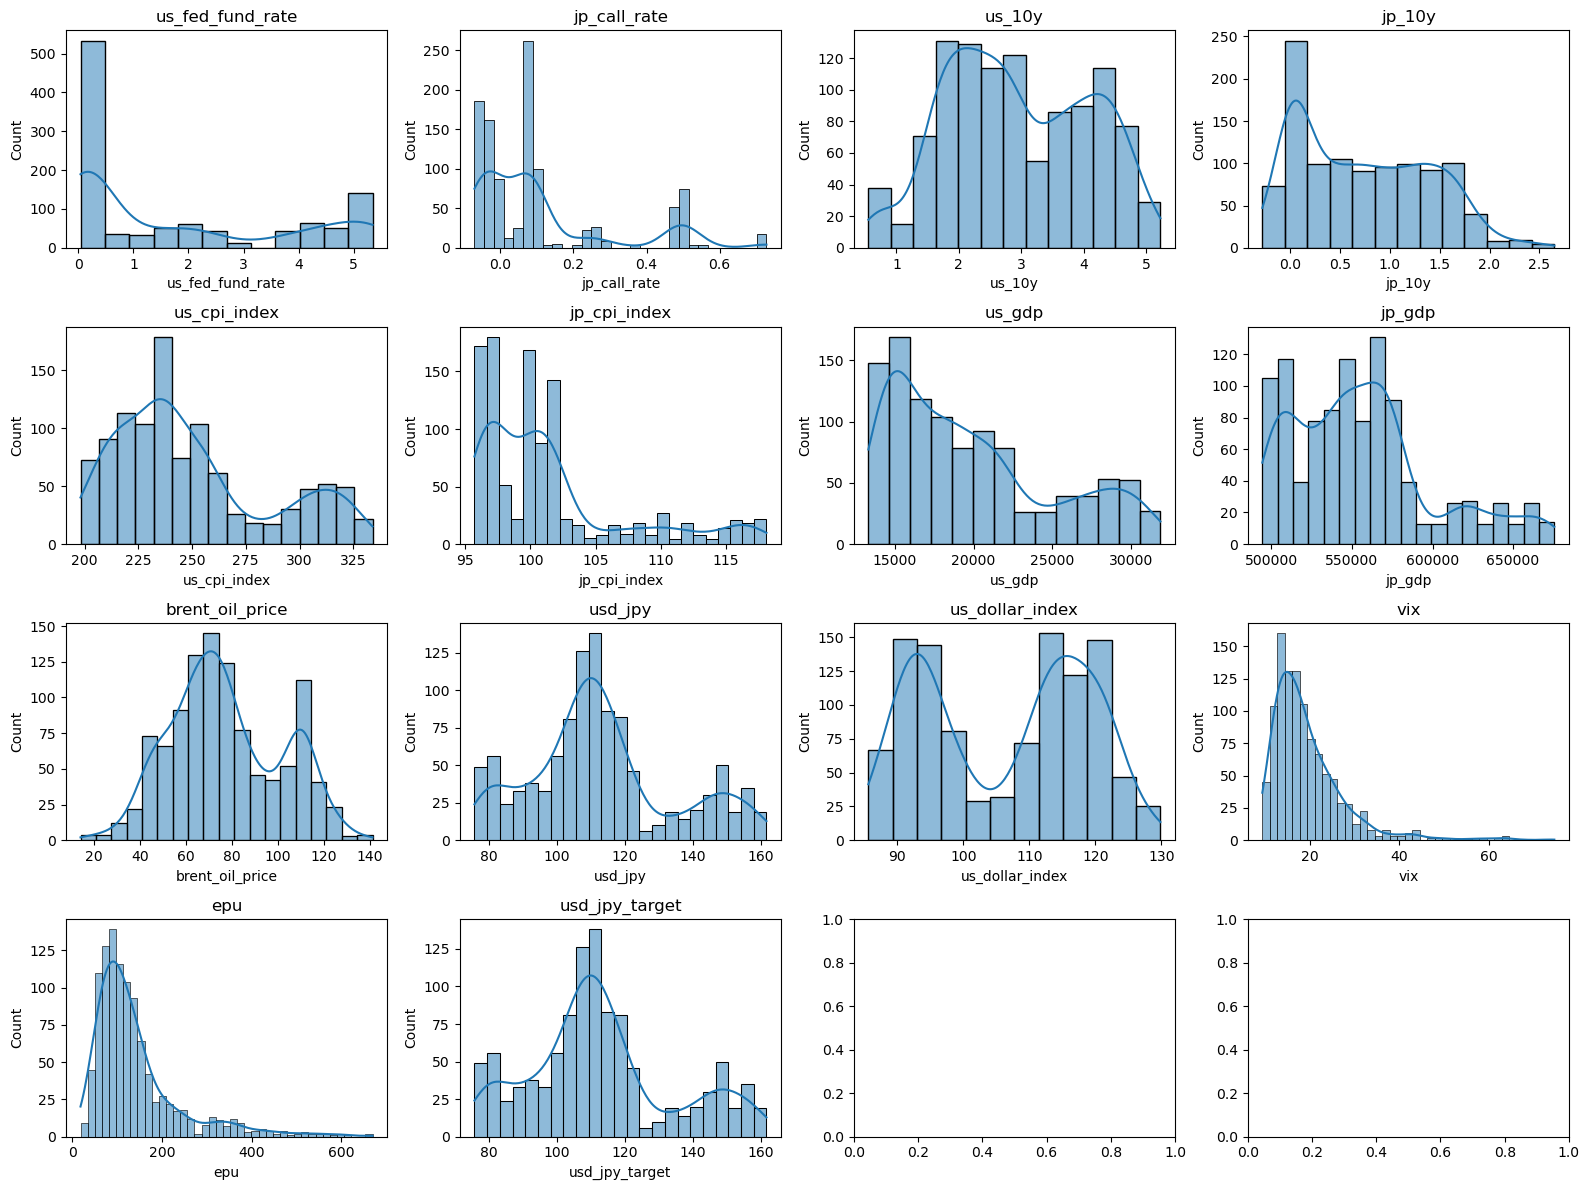

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col].dropna(), ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

The histograms above capture the behavior of each variable over the last 20 years for the US and/or Japan, and several tell a coherent economic story once put side by side.

us_fed_fund_rate and jp_call_rate, the two countries' respective central bank policy rates, are core drivers of USD/JPY movement. Central banks raise or lower rates primarily to manage inflation, and that decision has a direct secondary effect on currency strength: higher rates tend to attract foreign capital seeking better yield, which strengthens the currency. Over this 20-year window, Japan has held rates near zero almost continuously, while the US rate has moved through a full cycle, near-zero after the 2008 financial crisis and again through the 2020 pandemic, followed by aggressive hikes in recent years to combat inflation. This persistent gap between a near-static Japanese rate and a highly variable US rate is one of the central forces behind USD/JPY's long-run trend.

us_10y and jp_10y, the two countries' 10-year government bond yields, extend this same story into longer-term expectations. The spread between these two yields is often more informative than either yield alone, since it captures the relative attractiveness of holding US versus Japanese government debt. us_10y's histogram shows a wide, multi-peaked spread across roughly 1-5%, reflecting a full rate cycle, while jp_10y clusters tightly near 0 — the same ultra-low-rate environment visible in the call rate.

brent_oil_price matters for a different reason: Japan is heavily reliant on imported energy, while the US is both a major producer and consumer. Rising oil prices raise Japan's import costs more than they do the US's, which tends to weaken the yen relative to the dollar.

us_dollar_index (DXY) measures dollar strength against a broader basket of currencies, not the yen specifically. This makes it a useful diagnostic: if USD/JPY rises sharply while DXY stays flat, that points to yen-specific weakness rather than broad-based dollar strength - a distinction that matters for correctly attributing what's actually driving a given move.

vix and epu both capture uncertainty, but from different angles. VIX measures expected US stock market volatility, while EPU tracks how much news coverage reflects concern over policy uncertainty. Both tend to spike during the same crisis periods. Interestingly, the yen has historically behaved as a safe-haven currency during volatility spikes, so elevated VIX can coincide with yen strength - a relationship that runs somewhat counter to what the rate differential alone would predict. Elevated EPU, meanwhile, tends to correlate with reduced investment and more cautious market behavior generally.

us_gdp and jp_gdp both show a somewhat lumpy, non-smooth distribution, but this is a byproduct of GDP being a steadily growing index over a 20-year window rather than evidence of any economically meaningful multimodal pattern. The shape mostly reflects long-run economic growth, not distinct regimes the way the rate variables show.

Finally, usd_jpy and usd_jpy_target are the dependent variables at the center of this project - not predictors, but the outcome the model is trying to explain and forecast. usd_jpy is the exchange rate as observed each week; usd_jpy_target is that same rate shifted four weeks into the future, reframing the task as a genuine forecasting problem: given what's known today, what will USD/JPY be a month from now?

## 4. Time-Series Plots
Plot each variable across time to visually inspect trends, regime shifts, and any irregularities the histograms alone wouldn't reveal.

In [19]:
# TODO: line plot per variable over DATE

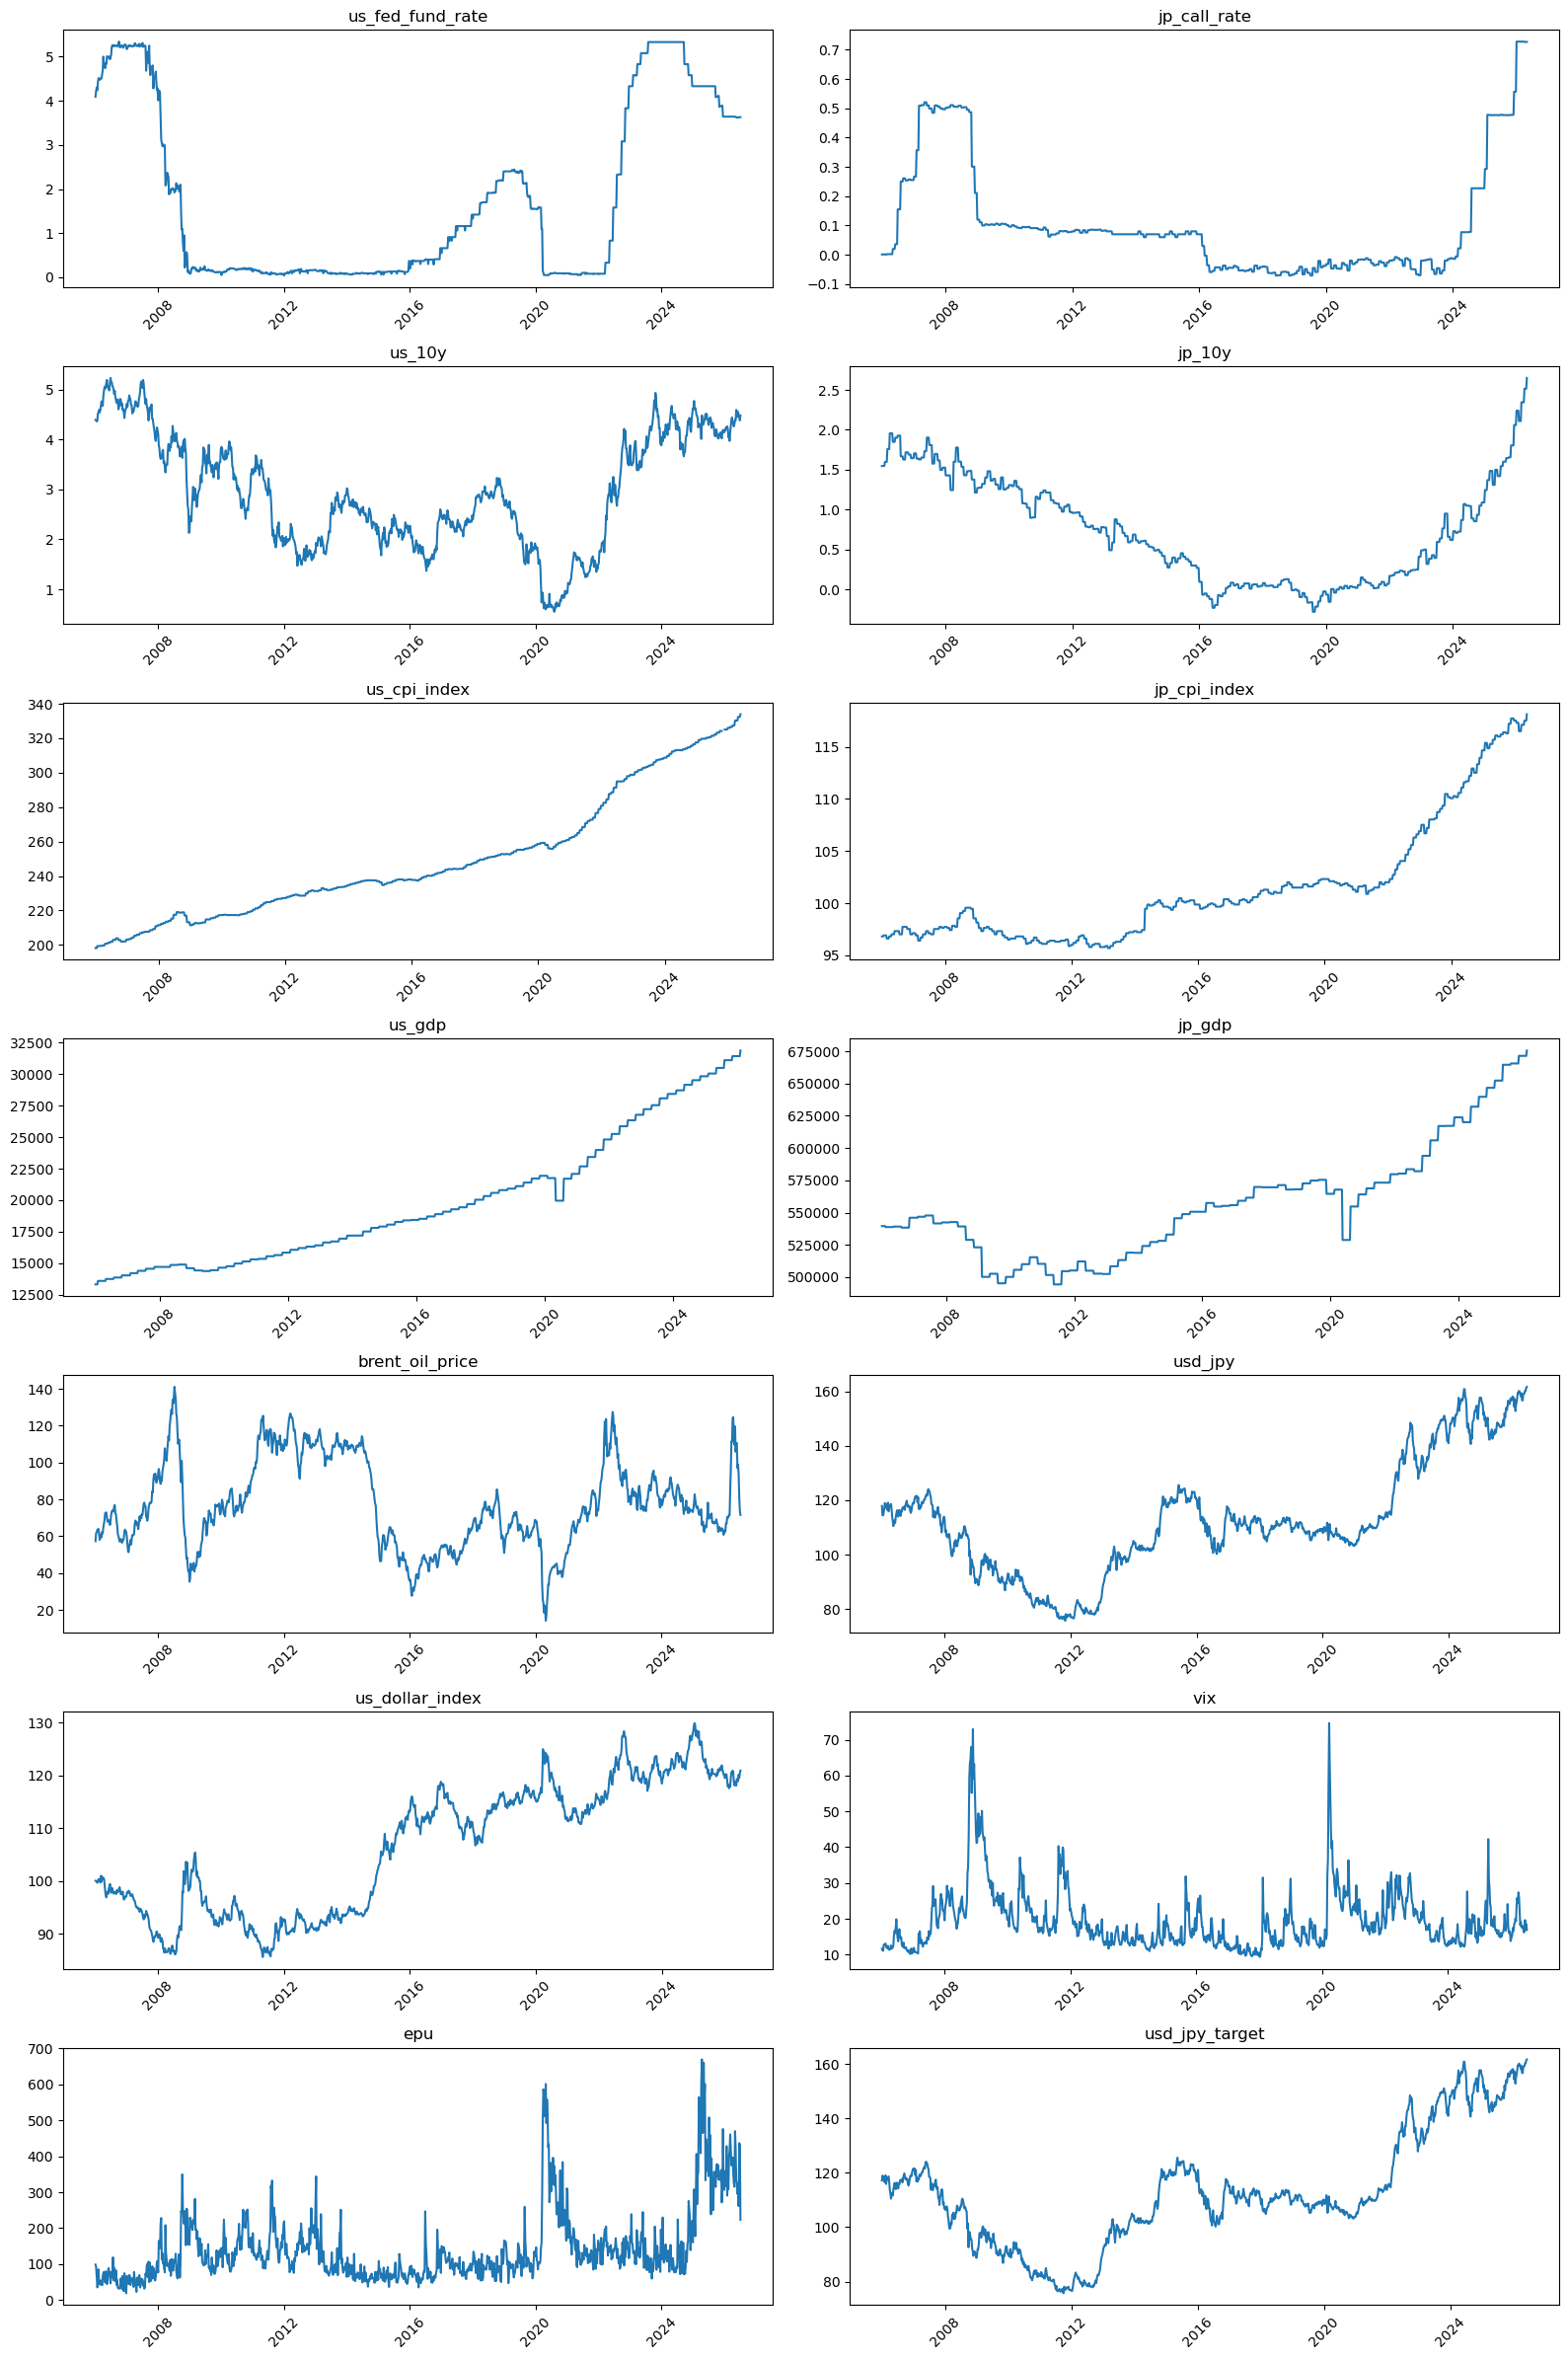

In [22]:
fig, axes = plt.subplots(7, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Overview: All Variables Across Time

Several known macroeconomic events are clearly visible across these charts, confirming they weren't just artifacts of the histogram shapes seen earlier.

`us_fed_fund_rate` shows two distinct near-zero stretches (2009-2015, and again 2020-2021), separated by a partial hiking attempt around 2018-2019, followed by a sharp climb starting in 2022. `jp_call_rate`, by contrast, stays near zero or negative for almost the entire window, only beginning to rise near the very end of the series.

`brent_oil_price` and `vix` both show sharp, dateable spikes around 2008-2009 and 2020, consistent with the financial crisis and the COVID pandemic respectively. `us_cpi_index` and `jp_cpi_index` both show a visible acceleration in slope starting around 2021, matching the post-pandemic inflation surge. `us_gdp` and `jp_gdp` both show a brief, sharp dip around 2020, the clearest single marker of the COVID recession in the whole dataset.

`usd_jpy` and `usd_jpy_target` show a long-run drift: relatively range-bound through the middle years of the series, followed by a sustained, dramatic climb from roughly 2021 onward. This later climb is the central trend this project is trying to explain and forecast.

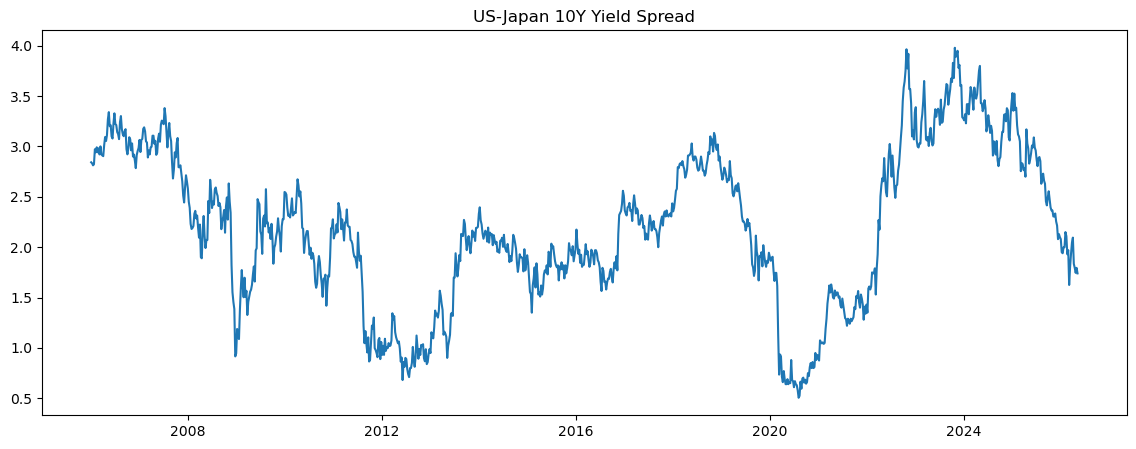

In [23]:
df['yield_spread'] = df['us_10y'] - df['jp_10y']
plt.figure(figsize=(14,5))
plt.plot(df.index, df['yield_spread'])
plt.title('US-Japan 10Y Yield Spread')
plt.show()

### US-Japan 10-Year Yield Spread

This engineered feature (`us_10y - jp_10y`) captures the relative attractiveness of holding US versus Japanese government debt. It's a single number instead of two separate yields, and it's often more informative than either yield alone for explaining currency movement.

The spread ranges from roughly 0.5 to 4.0 percentage points across the window and shows a clear cyclical pattern. It narrows sharply during periods of market stress (visible troughs around 2011-2012 and again around 2020), and it widens during periods of US monetary tightening relative to Japan (2016-2018, and again 2022-2023, reaching the highest levels in the whole series).

Notably, the 2009-2012 period had a moderately elevated spread but actually coincided with yen strength, not weakness. This is a case where the simple spread-driven theory breaks down. Carry-trade unwinding and safe-haven demand for the yen during the global financial crisis appear to have temporarily overridden the rate-differential relationship. This suggests the yield spread is a meaningful predictor under normal market conditions, but its relationship with USD/JPY may not hold consistently during acute crisis periods, which is worth keeping in mind when interpreting the model's later feature importance results.

### Inflation vs. 2% Target

Converting CPI to year-over-year percentage change to compare each country's inflation directly against the commonly cited 2% target.

C:\Users\Matt\AppData\Local\Temp\ipykernel_2092\409441806.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['us_inflation_yoy'] = df['us_cpi_index'].pct_change(periods=52) * 100
C:\Users\Matt\AppData\Local\Temp\ipykernel_2092\409441806.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['jp_inflation_yoy'] = df['jp_cpi_index'].pct_change(periods=52) * 100


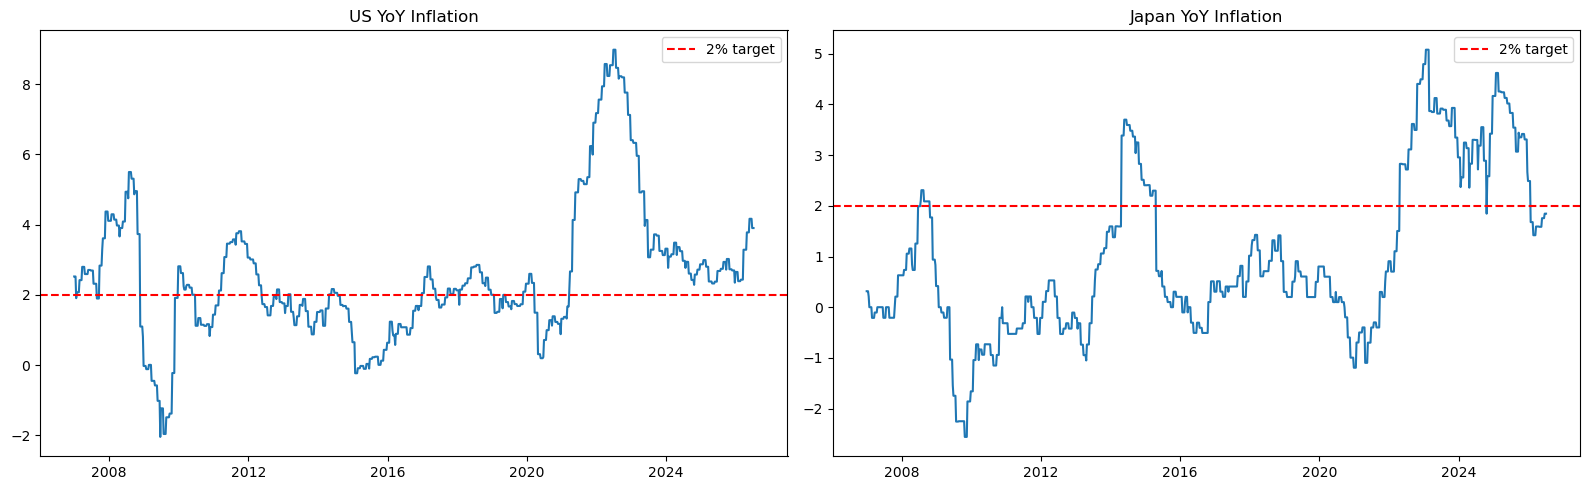

In [24]:
df['us_inflation_yoy'] = df['us_cpi_index'].pct_change(periods=52) * 100
df['jp_inflation_yoy'] = df['jp_cpi_index'].pct_change(periods=52) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df.index, df['us_inflation_yoy'])
axes[0].axhline(y=2, color='red', linestyle='--', label='2% target')
axes[0].set_title('US YoY Inflation')
axes[0].legend()

axes[1].plot(df.index, df['jp_inflation_yoy'])
axes[1].axhline(y=2, color='red', linestyle='--', label='2% target')
axes[1].set_title('Japan YoY Inflation')
axes[1].legend()

plt.tight_layout()
plt.show()

Both countries oscillate above and below the 2% line for most of the window, which is expected. The clearest feature in both charts is a sharp, sustained breakout well above 2% starting around 2021, matching the post-pandemic inflation surge already visible as a slope change in the raw CPI charts. This confirms that surge wasn't just a shift in the index's growth rate in the abstract, it was a genuine departure from the long-standing inflation target in both countries at the same time.

## 5. Bivariate Analysis - Features vs. Target
Scatterplots of each predictor against `usd_jpy_target`, to visually assess relationship shape and strength before quantifying it.

In [13]:
# TODO: scatterplot per feature vs usd_jpy_target

## 6. Correlation Analysis
Pearson correlation coefficients, ranked against the target, plus a full correlation heatmap to spot redundancy among predictors.

In [6]:
# TODO: df.corr()['usd_jpy_target'].sort_values()
# TODO: sns.heatmap(df.corr(), annot=True)

In [ ]:
# Ranked correlation against the target
df.corr()['usd_jpy_target'].sort_values(ascending=False)

In [ ]:
# Full correlation heatmap, all 13 variables
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Weekly Macro Variables')
plt.show()

## 7. Initial Observations
Summary of findings: which features show the strongest relationship to the target, which look weak or redundant, and what this suggests for feature engineering and modeling.

In [7]:
# TODO: written summary (markdown) — no code needed here, just notes